# Lekcija 2: Aritmetičke operacije nad slikama

Budući da je slika dvodimenzionalno polje brojeva (Lekcija 1), za njezinu se obradu mogu koristiti osnovne aritmetičke operacije: dodavanje konstante za posvjetljivanje, oduzimanje za zatamnjivanje, miješanje dviju slika pomoću ponderiranog prosjeka itd. Ova lekcija prikazuje nekoliko primjera i ističe važan detalj: kada su slike pohranjene kao 8-bitni cijeli brojevi bez predznaka, važno je *kako* izvodite aritmetičke operacije.


In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## Posvjetljivanje: dodavanje konstante

Vrijednost piksela predstavlja količinu svjetlosti, pa bi dodavanje pozitivne konstante svakom pikselu trebalo posvijetliti cijelu sliku. Isprobajmo to izravno pomoću biblioteke NumPy.


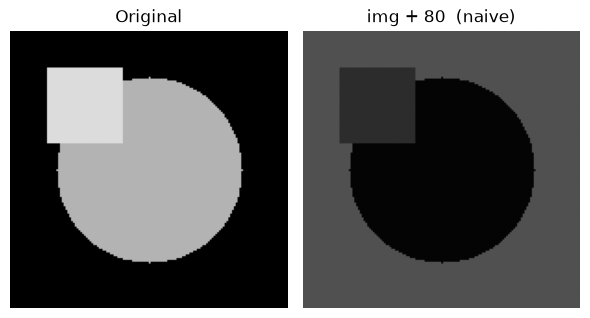

In [2]:
img = np.zeros((150, 150), dtype=np.uint8)
cv2.circle(img, (75, 75), 50, 180, -1)

brightened_naive = img + np.uint8(80)

fig, axes = plt.subplots(1, 2, figsize=(6, 3.5))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[1].imshow(brightened_naive, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('img + 80  (naive)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

Pažljivo pogledajte krug: umjesto da postane *svjetliji*, zapravo je postao *tamniji*. Nešto je pošlo po zlu.


## Problem: `uint8` i prelijevanje vrijednosti

8-bitni cijeli broj bez predznaka može predstavljati samo vrijednosti od 0 do 255. Stoga izraz `220 + 80 = 300` daje rezultat koji ne stane u jedan bajt. Aritmetika biblioteke NumPy za tip `uint8` koristi **kružno prelijevanje** (poput brojača prijeđenih kilometara u automobilu koji nakon najveće vrijednosti ponovno kreće od nule), pri čemu bez upozorenja izračunava `300 mod 256 = 44` umjesto **ograničavanja** na 255. To je isto ponašanje pri prelijevanju koje se javlja kod cjelobrojnih tipova s fiksnim brojem bitova na niskoj razini; NumPy ga jednostavno primjenjuje bez upozorenja.


In [3]:
sample_values = np.array([200, 250, 220])

print('original values:      ', sample_values)
print('naive (uint8) + 80:   ', sample_values.astype(np.uint8) + np.uint8(80), '  <- wrapped around, not clamped!')
print('what we actually want:', np.clip(sample_values + 80, 0, 255))

original values:       [200 250 220]
naive (uint8) + 80:    [24 74 44]   <- wrapped around, not clamped!
what we actually want: [255 255 255]


## Rješenje: aritmetika sa zasićenjem

Aritmetičke funkcije biblioteke OpenCV (`cv2.add`, `cv2.subtract`, ...) koriste **aritmetiku sa zasićenjem**: rezultati se ograničavaju na dopušteni raspon (0–255 za tip `uint8`) umjesto kružnog prelijevanja. To je gotovo uvijek željeno ponašanje.


pixel value, original:   220
pixel value, naive (wrapped):     44
pixel value, cv2.add (saturated): 255


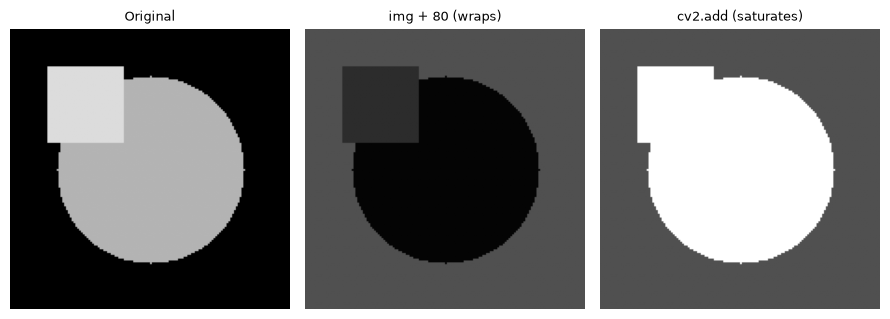

In [4]:
brightened_saturated = cv2.add(img, 80)

print('pixel value, original:  ', img[40, 40])
print('pixel value, naive (wrapped):    ', brightened_naive[40, 40])
print('pixel value, cv2.add (saturated):', brightened_saturated[40, 40])

fig, axes = plt.subplots(1, 3, figsize=(9, 3.5))
for ax, im, title in zip(axes, [img, brightened_naive, brightened_saturated],
                          ['Original', 'img + 80 (wraps)', 'cv2.add (saturates)']):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

Uz zasićenje svaki piksel postaje svjetliji ili ostaje na najvećoj vrijednosti &mdash; nikada ne postaje tamniji zbog kružnog prelijevanja. Isti princip vrijedi za funkciju `cv2.subtract` na donjoj granici raspona (rezultat se ograničava na 0 umjesto prelijevanja u velik pozitivan broj).


## Posvjetljivanje samo dijela slike pomoću maske

Često želite selektivno prilagoditi svjetlinu &mdash; primjerice, posvijetliti objekt u prvom planu bez promjene pozadine. Ako imate binarnu masku (dobivenu pragovanjem ili segmentacijom), posvijetljeni rezultat kopirajte samo na mjestima gdje maska ima vrijednost različitu od nule.


In [ ]:
photo = cv2.imread('../img/sheepdog.jpg')
foreground_mask = cv2.imread('../img/sheepdog_mask.png', cv2.IMREAD_GRAYSCALE)

fully_brightened = cv2.add(photo, np.full_like(photo, 60))
result = photo.copy()
result[foreground_mask > 0] = fully_brightened[foreground_mask > 0]

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, im, title in zip(axes,
                          [cv2.cvtColor(photo, cv2.COLOR_BGR2RGB), foreground_mask, cv2.cvtColor(result, cv2.COLOR_BGR2RGB)],
                          ['Original', 'Mask (foreground)', 'Only foreground brightened']):
    ax.imshow(im, cmap='gray' if im.ndim == 2 else None)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f'dog pixel (BGR), before -> after:   {photo[119, 160]} -> {result[119, 160]}')
print(f'grass pixel (BGR), before -> after: {photo[5, 5]} -> {result[5, 5]}')

<p class="image-attribution">Izvor slike: <a href="https://commons.wikimedia.org/wiki/File:Dog_walking_sideview_grass.JPG" target="_blank" rel="noopener">Wikimedia Commons</a></p>


`cv2.add` (i nekoliko drugih funkcija biblioteke OpenCV) izravno prihvaća i argument `mask`, kojim se upravo takav odabir i kopiranje izvode u jednom pozivu: `cv2.add(photo, 60, mask=foreground_mask)` &mdash; upisuje samo u područje označeno maskom, dok ostatak odredišta ostavlja nepromijenjenim.


## Miješanje dviju slika

Ponderirani zbroj dviju slika &mdash; **postupni prijelaz pretapanjem** (engl. *cross-dissolve*) &mdash; predstavlja generalizaciju iste aritmetike sa zasićenjem: funkcija `cv2.addWeighted(a, alpha, b, beta, gamma)` izračunava `a*alpha + b*beta + gamma` uz zasićenje.


In [ ]:
img_a = cv2.imread('../img/sheepdog.jpg')
img_b = cv2.imread('../img/lhasa_apso.jpg')
img_b = cv2.resize(img_b, (img_a.shape[1], img_a.shape[0]))  # match dimensions for addWeighted

fig, axes = plt.subplots(1, 5, figsize=(13, 3))
for ax, alpha in zip(axes, [0.0, 0.25, 0.5, 0.75, 1.0]):
    blended = cv2.addWeighted(img_a, 1 - alpha, img_b, alpha, 0)
    ax.imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
    ax.set_title(f'alpha={alpha}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

<p class="image-attribution">Izvori slika: <a href="https://commons.wikimedia.org/wiki/File:Dog_walking_sideview_grass.JPG" target="_blank" rel="noopener">Wikimedia Commons</a>, <a href="https://commons.wikimedia.org/wiki/File:Lhasaapso.jpg" target="_blank" rel="noopener">Wikimedia Commons</a></p>


## Računanje razlike između slika

Oduzimanje dviju slika (uz apsolutnu vrijednost, kako bi oba smjera promjene bila jednako važna) ističe upravo ono po čemu se one razlikuju. To je osnova jednostavne detekcije gibanja i promjena, a isti ćemo postupak ponovno koristiti u kasnijim lekcijama pri usporedbi rekonstrukcija s referentnim podacima (engl. *ground truth*).


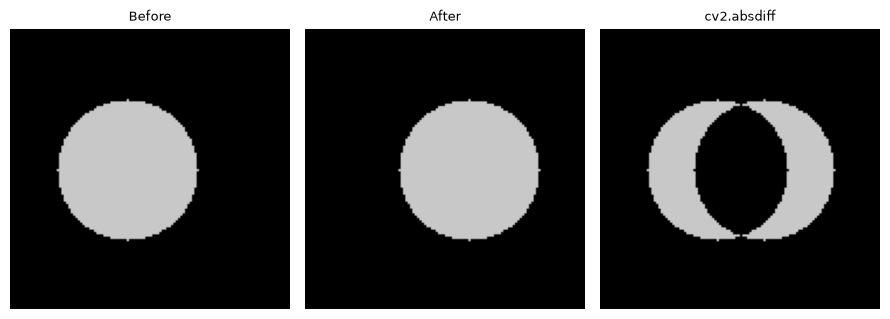

In [7]:
before = np.zeros((120, 120), dtype=np.uint8)
cv2.circle(before, (50, 60), 30, 200, -1)

after = np.zeros((120, 120), dtype=np.uint8)
cv2.circle(after, (70, 60), 30, 200, -1)  # the circle moved

difference = cv2.absdiff(before, after)

fig, axes = plt.subplots(1, 3, figsize=(9, 3.5))
for ax, im, title in zip(axes, [before, after, difference], ['Before', 'After', 'cv2.absdiff']):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

Slika razlike ima vrijednost nula na svim mjestima na kojima nije bilo promjene, a svijetla je upravo tamo gdje se krug nalazio prije ili se nalazi sada &mdash; osim u središnjem području preklapanja, gdje je krug prisutan u oba kadra.


### Zadaci

1. Predvidite, a zatim provjerite što funkcija `cv2.subtract(img, 150)` radi pikselu čija je vrijednost `100` &mdash; dolazi li do kružnog prelijevanja kao kod jednostavnog zbrajanja u biblioteci NumPy ili do zasićenja?
2. Upotrijebite funkciju `cv2.add` izravno s argumentom `mask` (umjesto ručnog kopiranja pomoću logičkog indeksiranja, kao u prethodnom primjeru) kako biste ponovili rezultat posvjetljivanja pomoću maske te provjerite daju li oba pristupa identičan rezultat.
3. `cv2.addWeighted` ne zahtijeva da zbroj `alpha + beta` bude jednak 1 (član `gamma` dodaje se zbroju obaju ponderiranih članova). Isprobajte `cv2.addWeighted(img_a, 1.0, img_b, 1.0, 0)` (običan zbroj sa zasićenjem, bez ponderiranog miješanja) i opišite kako se rezultat razlikuje od onoga za `alpha=0.5`.
